# VAR Analysis Notebook

## Workflow Summary

This notebook reports a standard reduced-form VAR analysis workflow: data setup, VAR($p$) estimation by OLS, stability verification, MA representation, Cholesky identification, and impulse response analysis.

`Data` -> `Lagged Matrices (Y, X)` -> `OLS (c, A_1,...,A_p, Sigma_u)` -> `Stability` -> `MA (C_h)` -> `Cholesky (P)` -> `Structural MA (\tilde{C}_h = C_h P)`


In [106]:
# 1) Imports

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Tuple

import utils as _utils
_utils = importlib.reload(_utils)

generate_synthetic_var_data = _utils.generate_synthetic_var_data
load_time_series = _utils.load_time_series
prepare_var_data = _utils.prepare_var_data
summarize_data = _utils.summarize_data
plot_raw_series_and_correlation = _utils.plot_raw_series_and_correlation
plot_stability_eigenvalues = _utils.plot_stability_eigenvalues
plot_irf = _utils.plot_irf
plot_irf_horizon_heatmap = _utils.plot_irf_horizon_heatmap

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)


## 1. Data Preparation

The analysis uses a multivariate time-series matrix with variables ordered as `var_names`. Data can be imported from external files (`csv`, `xlsx`) or generated synthetically for reproducible checks.

At this stage, missing values are removed (if requested), and the cleaned data matrix is used as the common input for all subsequent computations.


Data shape: (250, 3)


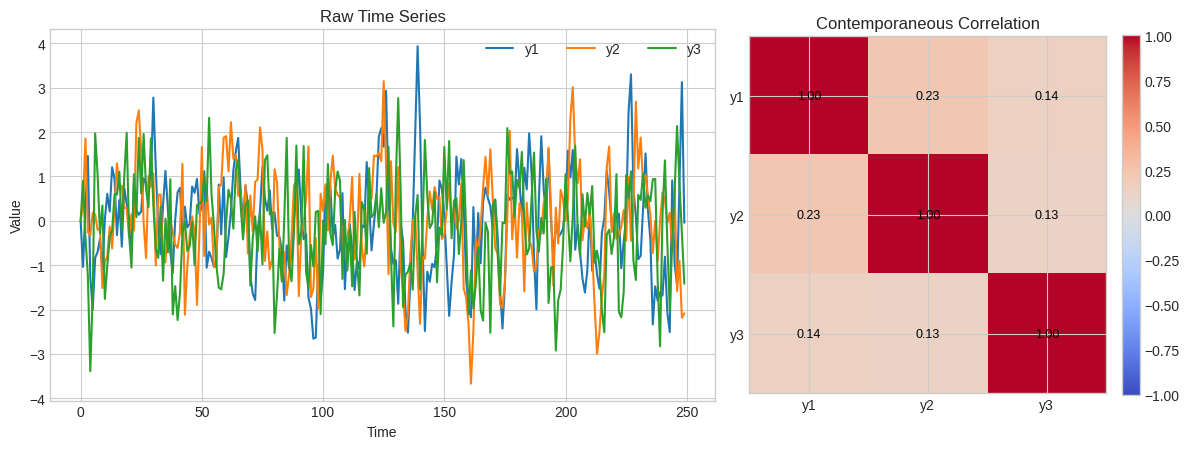

In [107]:
# 2) Data loading (functionized)

df = generate_synthetic_var_data(T=250, seed=42)
var_names = ["y1", "y2", "y3"]
data_df, data = prepare_var_data(df=df, var_names=var_names, dropna=True)

print("Data shape:", data.shape)

plot_raw_series_and_correlation(data_df=data_df, var_names=var_names)

## 2. Lag-Matrix Construction

Given lag order $p$, the VAR system is rewritten as a linear regression with stacked lag regressors:

$$
Y \in \mathbb{R}^{(T-p)\times k},\qquad X \in \mathbb{R}^{(T-p)\times kp}
$$

Each row of $X$ contains the concatenated lagged observations $(y_{t-1}', \dots, y_{t-p}')$. This transformation enables equation-by-equation OLS estimation in matrix form.


In [108]:
# 5) Result container and lag-matrix builder

@dataclass
class VARResults:
    coefs: np.ndarray
    intercept: np.ndarray
    residuals: np.ndarray
    sigma_u: np.ndarray
    p: int
    k: int

def make_lag_matrix(data: np.ndarray, p: int) -> Tuple[np.ndarray, np.ndarray]:
    if p < 1:
        raise ValueError("p must be >= 1")
    T, k = data.shape
    if T <= p:
        raise ValueError(f"Need T > p, got T={T}, p={p}")

    Y = data[p:]
    X_rows = []
    for t in range(p, T):
        lag_block = [data[t - lag] for lag in range(1, p + 1)]
        X_rows.append(np.concatenate(lag_block))

    X = np.asarray(X_rows)
    return Y, X


---
## 3. OLS Estimation

The parameter matrix is estimated by minimizing the Frobenius norm of residuals:

$$
\hat{B} = \arg\min_B \|Y - X_d B\|_F^2
$$

where $X_d$ denotes the design matrix (with intercept when included). The output includes intercept vector $c$, lag coefficient matrices $A_1,\dots,A_p$, residuals, and residual covariance $\Sigma_u$.


In [109]:
# 6) OLS estimator for VAR(p)

def fit_var_ols(data: np.ndarray, p: int, include_intercept: bool = True) -> VARResults:
    Y, X = make_lag_matrix(data, p)
    T_eff, k = Y.shape

    if include_intercept:
        X_design = np.hstack([np.ones((T_eff, 1)), X])
    else:
        X_design = X

    beta, *_ = np.linalg.lstsq(X_design, Y, rcond=None)

    if include_intercept:
        intercept = beta[0]
        coef_flat = beta[1:]
    else:
        intercept = np.zeros(k)
        coef_flat = beta

    coefs = coef_flat.T.reshape(k, p, k).transpose(1, 0, 2)
    Y_hat = X_design @ beta
    residuals = Y - Y_hat

    n_params = X_design.shape[1]
    dof = T_eff - n_params
    denom = dof if dof > 0 else T_eff
    sigma_u = (residuals.T @ residuals) / denom

    return VARResults(coefs=coefs, intercept=intercept, residuals=residuals, sigma_u=sigma_u, p=p, k=k)


In [110]:
# 7) Estimate VAR

p = 2  # lag order
results = fit_var_ols(data, p=p, include_intercept=True)

print("Intercept c:")
print(results.intercept)
print()
for lag in range(results.p):
    print(f"A_{lag + 1}:")
    print(results.coefs[lag])
    print()
print("Residual covariance Sigma_u:")
print(results.sigma_u)


Intercept c:
[-0.0387 -0.0029 -0.1305]

A_1:
[[0.6186 0.2546 0.1419]
 [0.0853 0.467  0.0178]
 [0.0162 0.3576 0.3236]]

A_2:
[[-0.173  -0.1432 -0.062 ]
 [-0.0113  0.0392 -0.0564]
 [ 0.0421 -0.1009 -0.1353]]

Residual covariance Sigma_u:
[[ 0.8504  0.0506 -0.0172]
 [ 0.0506  0.9678 -0.0689]
 [-0.0172 -0.0689  1.0372]]


---
## 4. Stability Check

For VAR($p$), stability is evaluated using the companion matrix $\mathcal{A}$:

$$
\mathcal{A} =
\begin{bmatrix}
A_1 & A_2 & \cdots & A_{p-1} & A_p \\ 
I_k & 0   & \cdots & 0       & 0   \\ 
0   & I_k & \cdots & 0       & 0   \\ 
\vdots & \vdots & \ddots & \vdots  & \vdots \\ 
0   & 0   & \cdots & I_k     & 0
\end{bmatrix}.
$$

The process is covariance-stationary when all eigenvalues lie strictly inside the unit circle:

$$
|\lambda_i(\mathcal{A})| < 1 \quad \forall i.
$$

This condition is checked before long-horizon MA coefficients and IRFs are interpreted.


Is the VAR stable? True
Eigenvalues:
[-0.156 +0.j      0.1507+0.3625j  0.1507-0.3625j  0.3782+0.2474j
  0.3782-0.2474j  0.5073+0.j    ]
Absolute eigenvalues:
[0.156  0.3926 0.3926 0.4519 0.4519 0.5073]


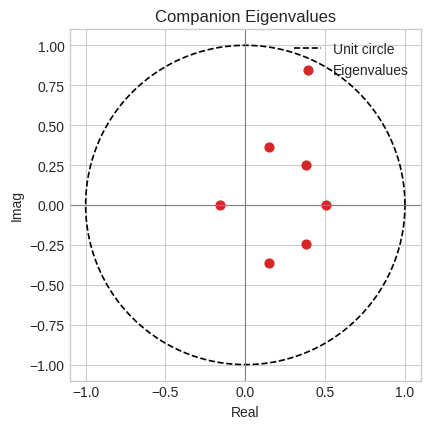

In [111]:
# 8) Companion matrix and stability check

def companion_matrix(coefs: np.ndarray) -> np.ndarray:
    p, k, _ = coefs.shape
    top = np.concatenate(coefs, axis=1)
    if p == 1:
        return top
    bottom = np.hstack([np.eye(k * (p - 1)), np.zeros((k * (p - 1), k))])
    return np.vstack([top, bottom])

def check_var_stability(coefs: np.ndarray, tol: float = 1e-10):
    A = companion_matrix(coefs)
    eigvals = np.linalg.eigvals(A)
    stable = np.all(np.abs(eigvals) < 1 - tol)
    return stable, eigvals

# 9) Run stability check

stable, eigvals = check_var_stability(results.coefs)
print("Is the VAR stable?", stable)
print("Eigenvalues:")
print(eigvals)
print("Absolute eigenvalues:")
print(np.abs(eigvals))
plot_stability_eigenvalues(eigvals)


--- 
## 5. MA Representation

A stable VAR admits an infinite-order moving-average representation. In lag-polynomial form:

$$
y_t = \mu + C(L)e_t, \qquad C(L)=\sum_{h=0}^{\infty} C_h L^h, \quad C_0=I_k.
$$

With Cholesky identification ($e_t = Pu_t$), the same system is written as

$$
y_t = \mu + \tilde{C}(L)u_t, \qquad \tilde{C}(L)=C(L)P,
$$

so coefficient-by-coefficient, $\tilde{C}_h = C_hP$.


In [112]:
# 10) Define VAR -> MA conversion

def var_to_ma(coefs: np.ndarray, horizon: int) -> np.ndarray:
    p, k, _ = coefs.shape
    C = np.zeros((horizon + 1, k, k))
    C[0] = np.eye(k)
    for h in range(1, horizon + 1):
        acc = np.zeros((k, k))
        for j in range(1, p + 1):
            if h - j >= 0:
                acc += coefs[j - 1] @ C[h - j]
        C[h] = acc
    return C
    
horizon = 20
ma_coefs = var_to_ma(results.coefs, horizon=horizon)
if not stable:
    print("Warning: VAR is not stable, so long-horizon MA/IRF may diverge.")
print("C_0:")
print(ma_coefs[0])
print("\nC_1:")
print(ma_coefs[1])


C_0:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

C_1:
[[0.6186 0.2546 0.1419]
 [0.0853 0.467  0.0178]
 [0.0162 0.3576 0.3236]]


---

## 6. Cholesky Identification

To obtain orthogonal structural shocks, the residual covariance is factorized as:

$$
\Sigma_u = PP',\qquad e_t = Pu_t,\qquad \mathbb{E}[u_tu_t']=I_k
$$

Under Cholesky ordering, variable order in the data determines contemporaneous identification restrictions.


In [113]:
# 12) Define Cholesky identification

def identify_cholesky(sigma_u: np.ndarray, ridge: float = 1e-10) -> np.ndarray:
    try:
        return np.linalg.cholesky(sigma_u)
    except np.linalg.LinAlgError:
        return np.linalg.cholesky(sigma_u + ridge * np.eye(sigma_u.shape[0]))
        
# 13) Compute impact matrix P

impact_matrix = identify_cholesky(results.sigma_u)
print("Impact matrix P (Cholesky):")
print(impact_matrix)


Impact matrix P (Cholesky):
[[ 0.9222  0.      0.    ]
 [ 0.0549  0.9822  0.    ]
 [-0.0186 -0.0691  1.0159]]


--- 
## 7. IRF Computation

Impulse responses are read from structural MA coefficients:

$$
\tilde{C}_h = C_hP,
\qquad
\mathrm{IRF}_{ij}(h) = \frac{\partial y_{i,t+h}}{\partial u_t^{(j)}} = (\tilde{C}_h)_{ij}.
$$

The element $(i,j)$ of $\tilde{C}_h$ is interpreted as the response of variable $i$ at horizon $h$ to a one-unit structural shock in variable $j$ at time $t$.

Example notation: `y1 <- y2_shock` denotes the response path of `y1` to the second structural shock.


IRF at h=0 (impact response, y <- u):
[[ 0.9222  0.      0.    ]
 [ 0.0549  0.9822  0.    ]
 [-0.0186 -0.0691  1.0159]]


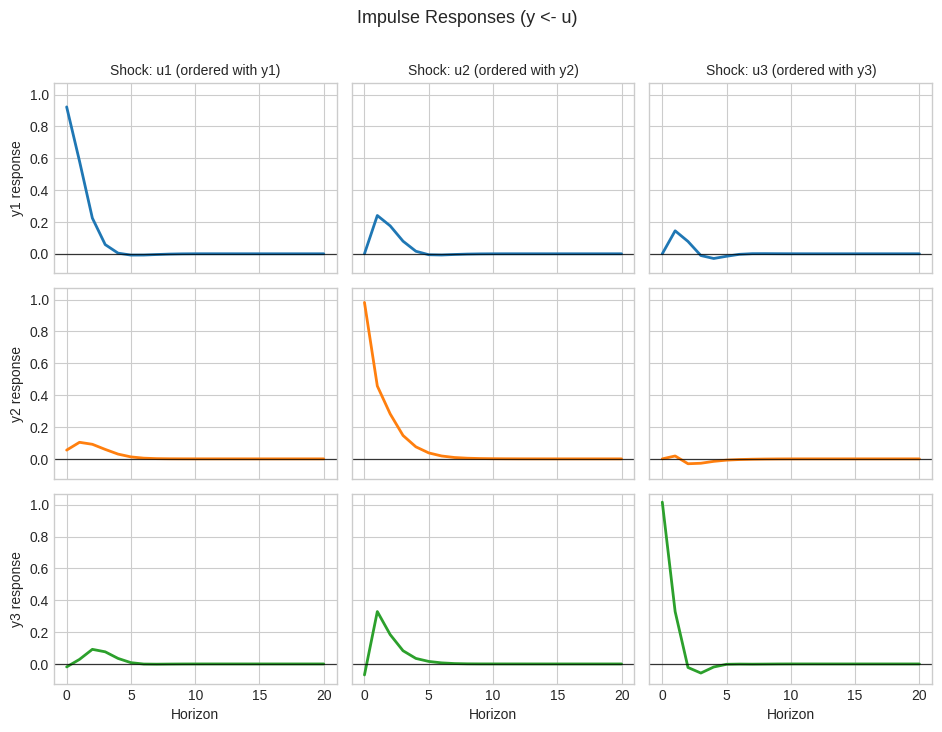

In [114]:
# 14) Define IRF computation

def compute_irf(ma_coefs: np.ndarray, impact_matrix: np.ndarray) -> np.ndarray:
    # Theta[h, i, j]: response of y_i at horizon h to one-unit structural shock u_j
    return np.einsum("hij,jk->hik", ma_coefs, impact_matrix)

# 15) Compute IRFs
irf = compute_irf(ma_coefs, impact_matrix)
print("IRF at h=0 (impact response, y <- u):")
print(irf[0])

# 16) Plot IRFs
shock_names = [f"u{j + 1} (ordered with {name})" for j, name in enumerate(var_names)]
plot_irf(irf=irf, var_names=var_names, shock_names=shock_names)
